<>:5: SyntaxWarning: invalid escape sequence '\h'
<>:5: SyntaxWarning: invalid escape sequence '\h'
C:\Users\admin\AppData\Local\Temp\ipykernel_46336\2354192371.py:5: SyntaxWarning: invalid escape sequence '\h'
  housing = pd.read_csv('D:\housing.csv')     #var类型为DataFrame


检查数据基本信息：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None
----------------------------------------------------------------------------------------------------
查看数据基本统计信息：
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.00000

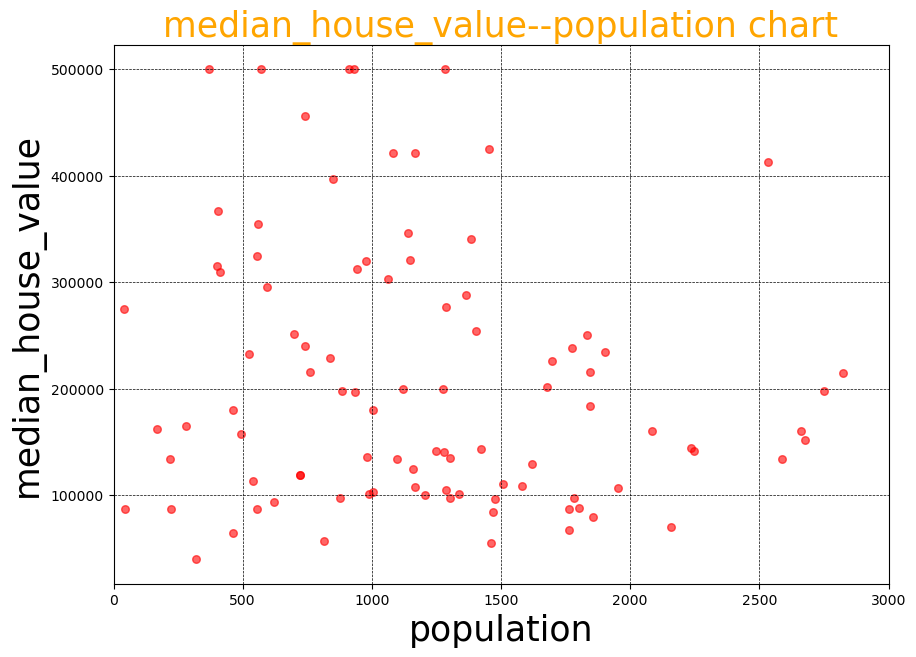

----------------------------------------------------------------------------------------------------
创建sin正弦曲线图像：


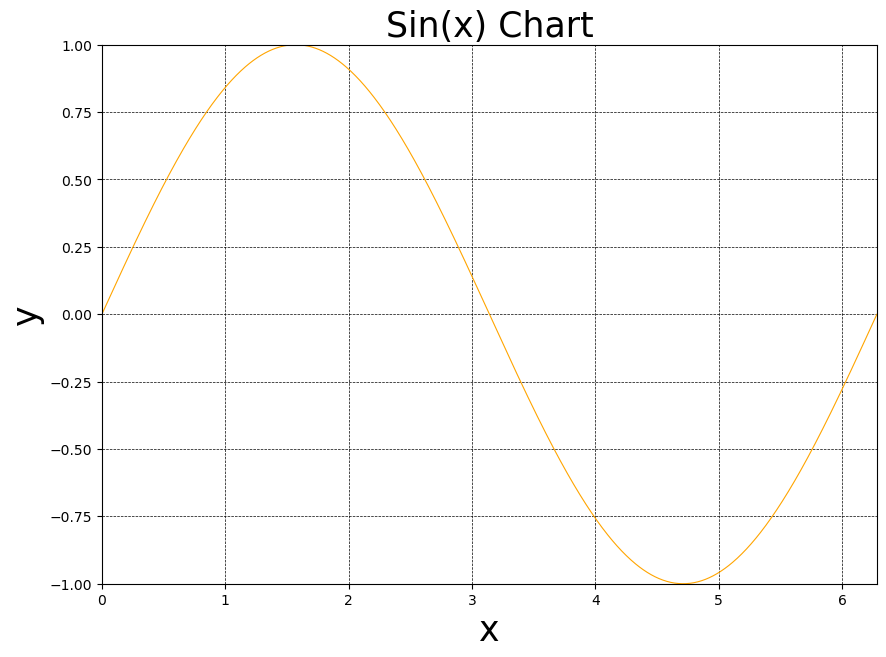

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

housing = pd.read_csv('D:\housing.csv')     #var类型为DataFrame
print("检查数据基本信息：")
print(housing.info())
print('-'*100)

print("查看数据基本统计信息：")
print(housing.describe())
print('-'*100)

print("检查数据缺失值：")
print(housing.isna())
print(housing.isna().sum())
print('-'*100)

print("数据前5行数据")
print(housing.head())
print('-'*100)

print("=====处理缺失值======")
tmp_mean = housing['total_bedrooms'].mean()     #取列平均数
print("total_bedrooms列的平均数：", tmp_mean)
print("填充缺失值前的列方差：", housing['total_bedrooms'].var())     #显示填充前的方差（对比出填充效果）

tmp_dict = {'total_bedrooms': tmp_mean}     #设置临时字典dict
housing.fillna(tmp_dict, inplace=True)     #填充缺失值
print("填充缺失值后的列方差：", housing['total_bedrooms'].var())     #显示填充后的方差

print("缺失值填充完毕：")
print(housing.isna().sum())
print('-'*100)

print("检查中位数房价" + "(展示中位数房价前5高的对应数据行)：")
print(housing.nlargest(5, ['median_house_value']))

print("中位数房价平均数：")
print(housing['median_house_value'].mean())
print('-'*100)

print("查看中位数房价与人口的关系：")
print("现随机抽样100份数据以作图表：")
num_sample:int = 100
x:float = 10.0
y:float = 7.0
plt.figure(1, figsize=(x,y))     #创建新画布

np.random.seed(250531)     #固定随机抽样的数据
SampleOfPopulWithPrice = housing.sample(num_sample)     #sample()随机抽抽取num_sample份数据

#scatter()绘制散点图
plt.scatter(
    SampleOfPopulWithPrice['population'], SampleOfPopulWithPrice['median_house_value'],     #传入x轴y轴数据
    s=30,     #设置散点大小
    color='red',     #设置散点颜色
    alpha=0.6,     #设置散点透明度
    marker='o',     #设置散点形状
)
plt.title("median_house_value--population chart", color = 'orange', fontsize = 25)     #添加图表标题
plt.xlabel("population", fontsize = 25)     #添加x轴标题
plt.ylabel("median_house_value", fontsize = 25)     #添加y轴标题
plt.xlim([0, 3000])     #规定x轴取值范围
plt.grid(True, linestyle='--', linewidth=0.5, color='black')     #设置图表背景虚线及其颜色
plt.show()     #展示图表
print('-'*100)

#创建正弦曲线图像
print("创建sin正弦曲线图像：")
plt.figure(2, figsize=(x,y))     #创建新画布
x_data = np.linspace(0, 2 * np.pi, 1000)     #初始化x轴数据
y_data = np.sin(x_data)      #初始化y轴数据


plt.plot(
    x_data,
    y_data,
    color='orange',
    linestyle='-',
    linewidth=0.8,
)
plt.title("Sin(x) Chart", color='black', fontsize = 25)
plt.xlabel("x", fontsize = 25)
plt.ylabel("y", fontsize = 25)
plt.xlim([0, np.pi*2])     #规定x轴取值范围
plt.ylim([-1, 1])     #规定y轴取值范围
plt.grid(True, linestyle='--', linewidth=0.5, color='black')     #设置图表背景虚线及其颜色
plt.show()
